In [1]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

data = []
for tr in table.find_all('tr'):
    tds = list(tr.find_all('td'))

    for td in tds:
        if td.find('a'):
            point = td.find('a').text
            temperature = tds[5].text
            humidity = tds[9].text

            data.append([point, temperature, humidity])

data

# csv가 아닌 리스트로 만들기
# 수업 진행은 이 방식을 먼저 할 것!
selected_cities = []
for i in data:
    if i[0] in ['서울', '인천', '대전', '대구', '광주', '부산', '울산']:
        selected_cities.append(i)

selected_cities

city_name_list = []
temperature_list = []
humidity_list = []
for i in selected_cities:
    city_name_list.append(i[0])
    temperature_list.append(float(i[1]))
    humidity_list.append(float(i[2]))

print(city_name_list, temperature_list, humidity_list)

['광주', '대구', '대전', '부산', '서울', '울산', '인천'] [27.0, 27.9, 27.9, 27.1, 28.2, 26.6, 27.6] [98.0, 78.0, 80.0, 80.0, 74.0, 78.0, 75.0]


<Figure size 640x480 with 0 Axes>

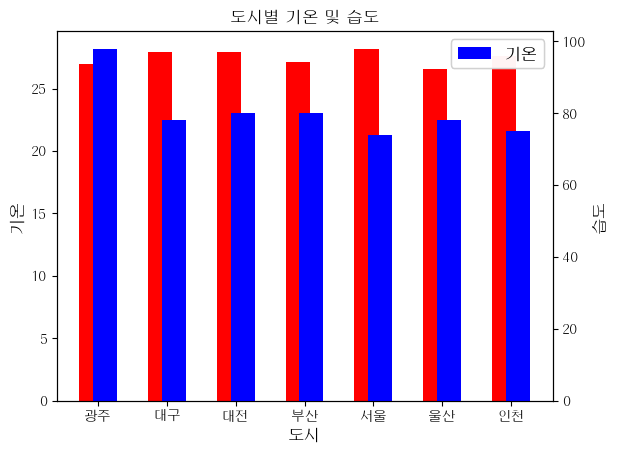

In [14]:
# bar() 메소드 이용한 이중 축 막대 그래프 만들기
import matplotlib.pyplot as plt

# Windows 한글 폰트 설정
# pip install matplotlib
import matplotlib as mpl
# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
# .get_name() 누락 주의!!!
font_name = mpl.font_manager.FontProperties(fname='C:/Windows/Fonts/HYGPRM.TTF').get_name()
mpl.rc('font', family=font_name)

figure = plt.figure()

x = [1, 2, 3, 4, 5, 6, 7]
y1 = temperature_list
y2 = humidity_list

# 그래프 그리기
fig, ax1 = plt.subplots()
ax2 = ax1.twinx() # 오른쪽에 y축 값 표시

bar_width = 0.35  # 막대 그래프 너비 설정
spacing = 0.2  # 막대 그래프 간격 설정

ax1.bar([i - spacing / 2 for i in x], y1, width=bar_width, color="red", label="기온")
ax2.bar([i + spacing / 2 for i in x], y2, width=bar_width, color="blue", label="습도")

# y 축 설정
ax1.set_ylabel('기온', fontsize=12) 
ax2.set_ylabel('습도', fontsize=12)

# x 축 설정
ax1.set_xlabel('도시', fontsize=12) 
ax1.set_xticks(x)
ax1.set_xticklabels(city_name_list)

# 타이틀, 범례 추가
plt.title("도시별 기온 및 습도")

ax1.legend(loc="center", bbox_to_anchor=(0.9, 1.11))
ax2.legend(loc="center", bbox_to_anchor=(0.9, 1.04))

plt.show()

In [91]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [50]:
# matplotlib.pyplot의 show 함수를 호출하지 않아도 주피터 노트북 안에서 그래프가 표시됨
# %matplotlib inline
import pandas as pd # 데이터 처리

df = pd.read_csv('weather.csv', index_col='point') # csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
df



,temperature,humidity
point,,
강릉,25.9,34
강진군,23.7,60
강화,23.3,50
거제,23.7,62
거창,24.0,60
...,...,...
합천,23.8,57
해남,21.9,75
홍성,23.8,58


In [71]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '부산', '울산']]
city_df

,temperature,humidity
point,,
서울,23.5,50
인천,22.8,50
대전,22.3,61
대구,23.2,58
광주,22.5,75
부산,24.5,51
울산,23.3,46


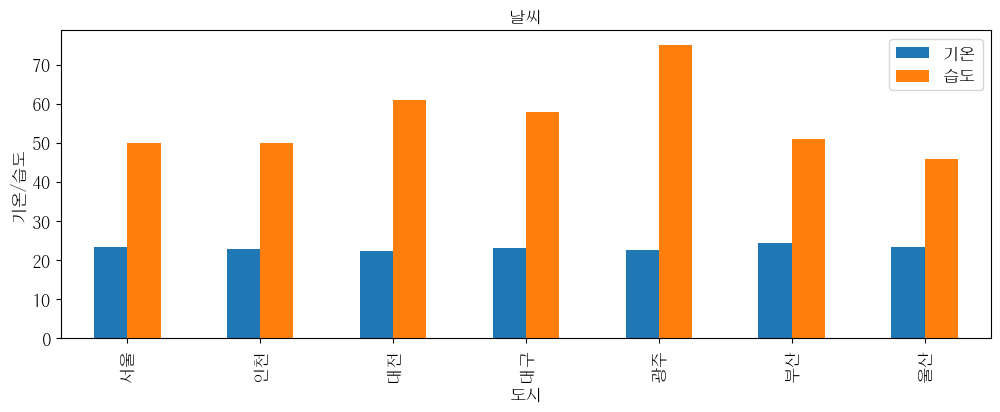

In [72]:
# Windows 한글 폰트 설정
# pip install matplotlib
import matplotlib as mpl

# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
# .get_name() 누락 주의!!!
font_name = mpl.font_manager.FontProperties(fname='C:/Windows/Fonts/HYGPRM.TTF').get_name()
mpl.rc('font', family=font_name)

# 차트 종류, 제목, 차트 크기, 범례, 폰트 크기 설정
ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)          # x축 정보 표시
ax.set_ylabel('기온/습도', fontsize=12)     # y축 정보 표시
ax.legend(['기온', '습도'], fontsize=12)    # 범례 지정

# import matplotlib.pyplot as plt # IDLE, 파이썬 인터프리터에서 그래프 표시
# plt.show()